In [81]:
%load_ext autoreload
%autoreload 2

# spatial
import geopandas as gpd
import xarray as xa
import rasterio
from rasterio import features
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# files
import os
import sys
from pathlib import Path

# general
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# custom
from coralshift.utils import config, file_ops
from coralshift.dataloading import get_data
from coralshift.plotting import spatial_plots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [127]:
from joblib import Parallel, delayed
import xarray as xa
import numpy as np
from tqdm import tqdm

def process_time_step(var_data, time_step, nx, ny):
    # Process each time slice independently
    grid = pyxarray.Grid2D(var_data.sel(time=time_step))
    filled = loess(grid, nx=nx, ny=ny)
    return filled.T  # Return the filled array for the time step

def apply_fill_loess_parallel(dataset: xa.Dataset, nx=2, ny=2, n_jobs=-1):
    """
    Parallelized version of apply_fill_loess to handle large datasets more efficiently.
    """
    buffered_dataset = dataset.copy(deep=True)
    buffered_data_vars = buffered_dataset.data_vars

    for var_name, var_data in tqdm(buffered_data_vars.items(), desc="Buffering variables"):
        if utils.check_var_has_coords(var_data):  # If the variable has time, latitude, and longitude coordinates
            if isinstance(buffered_dataset.time.values, np.datetime64):
                print("Multiple time values required for this operation.")
                continue
            else:
                # Parallel processing for each time step
                results = Parallel(n_jobs=n_jobs)(
                    delayed(process_time_step)(var_data, t, nx, ny)
                    for t in buffered_dataset.time
                )

                # Update the dataset with the filled results
                for idx, time_step in enumerate(buffered_dataset.time):
                    buffered_data_vars[var_name].loc[dict(time=time_step)] = results[idx]

        elif utils.check_var_has_coords(var_data, ["latitude", "longitude"]):
            grid = pyxarray.Grid2D(var_data.astype("float64"), geodetic=False)
            filled = loess(grid, nx=nx, ny=ny)

            # Transpose filled array if necessary
            if filled.shape != buffered_dataset[var_name].shape:
                filled = np.transpose(filled)

            buffered_dataset.update({var_name: (sorted(buffered_dataset[var_name].dims), filled)})
        else:
            print(f"Variable '{var_name}' does not meet coordinate requirements and will be skipped.")

    return buffered_dataset

# Simple thresholding suitability method

Thresholding CMIP6 data using Kleypas/Guan (https://doi.org/10.1371/journal.pone.0128831) values to investigate coincidence with reef occurrence: historic, present, and future.

Sticking to GBR as case study for now.


In [101]:
lats = [-30, 0]
lons = [140, 170]
resolution = 0.25
spatial_buffer = 2

## Ground truth data

In [47]:
# load coral presence data
config_class = config.Config(file_ops.read_yaml(config.config_dir / "config_test.yaml"))
config_class.resolution = resolution   # for now, to keep processing fast
config_class.lats = lats
config_class.lons = lons

unep_gdcr = get_data.ReturnRaster(config_info=config_class).return_raster(dataset="unep")["UNEP_GDCR"]

Loading UNEP_GDCR xarray at 0.004 degrees resolution.
loading from /maps-priv/maps/rt582/coralshift/data/ground_truth/UNEP_GDCR/rasters/unep_0-004_S90-1_N90-1_W180-1_E180-1.nc
	applying spatial buffering...
1 raster(s) to spatially buffer...


Buffering variables: 100%|██████████| 1/1 [00:00<00:00,  8.16it/s]


	resampling dataset to 0.25 degree(s) resolution...

Resampling pipeline: written raster CRS to EPSG:4326


## Temperature
Both potential temperature at seafloor and sst. Currently just for a single model ensemble 

TODO: expand to more to get spread

In [129]:
# currently looking at historic
years = [1950, 2014]

Buffering variables: 100%|██████████| 1/1 [00:15<00:00, 15.35s/it]


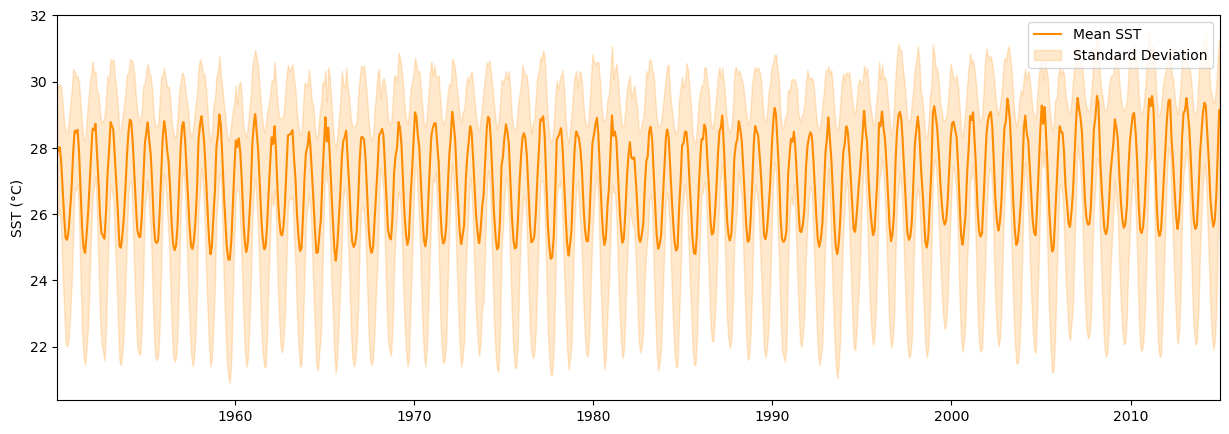

In [130]:
# SST
sst_dir_fp = config.cmip6_data_dir / "EC-Earth3P-HR/r1i1p2f1/regridded/tos"
sst_ts = xa.open_mfdataset(sst_dir_fp.glob("*.nc"))
# crop to case study area and time
sst_ts = sst_ts.sel(time=slice(f"{min(years)}-01-01", f"{max(years)}-12-31"), lat=slice(*lats), lon=slice(*lons))
# format ds
sst_ts = sst_ts.rename({"lon": "longitude", "lat": "latitude"})
# spatially buffer
sst_ts = apply_fill_loess_parallel(sst_ts, nx=spatial_buffer, ny=spatial_buffer, n_jobs=-1)
# resample (linear interpolation) to weekly
sst_ts = sst_ts.resample(time="1W").interpolate("linear")

# plot timeseries (average over the area)
sst_mean = sst_ts["tos"].mean(dim=["latitude", "longitude"])
sst_std = sst_ts["tos"].std(dim=["latitude", "longitude"])

plt.figure(figsize=(15, 5))
plt.plot(sst_mean.time, sst_mean, label="Mean SST", color="darkorange")
plt.fill_between(
    sst_mean.time,
    sst_mean - sst_std,
    sst_mean + sst_std,
    color="darkorange",
    alpha=0.2,
    label="Standard Deviation"
)
plt.xlim([sst_mean.time[0], sst_mean.time[-1]])
plt.ylabel("SST (°C)")
plt.legend()

Buffering variables: 100%|██████████| 1/1 [00:10<00:00, 10.02s/it]


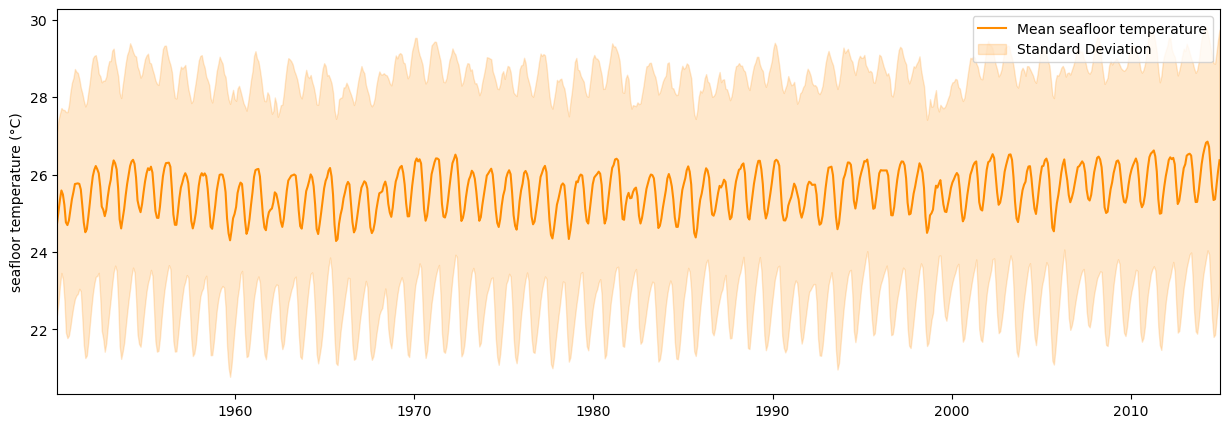

In [131]:
# THETAO
thetao_dir_fp = config.cmip6_data_dir / "EC-Earth3P-HR/r1i1p2f1/regridded/thetao"
thetao_ts = xa.open_mfdataset(thetao_dir_fp.glob("*.nc"))
# crop to case study area and time
thetao_ts = thetao_ts.sel(time=slice(f"{min(years)}-01-01", f"{max(years)}-12-31"), lat=slice(*lats), lon=slice(*lons))
# format ds
thetao_ts = thetao_ts.rename({"lon": "longitude", "lat": "latitude"}).drop_vars("time_bnds")
# spatially buffer
thetao_ts = apply_fill_loess_parallel(thetao_ts, nx=spatial_buffer, ny=spatial_buffer, n_jobs=-1)
# resample (linear interpolation) to weekly
thetao_ts = thetao_ts.resample(time="1W").interpolate("linear")

# plot timeseries (average over the area)
thetao_mean = buffered_thetao["thetao"].mean(dim=["latitude", "longitude"])
thetao_std = buffered_thetao["thetao"].std(dim=["latitude", "longitude"])

plt.figure(figsize=(15, 5))
plt.plot(thetao_mean.time, thetao_mean, label="Mean seafloor temperature", color="darkorange")
plt.fill_between(
    thetao_mean.time,
    thetao_mean - thetao_std,
    thetao_mean + thetao_std,
    color="darkorange",
    alpha=0.2,
    label="Standard Deviation"
)
plt.xlim([thetao_mean.time[0], thetao_mean.time[-1]])
plt.ylabel("seafloor temperature (°C)")
plt.legend()

In [132]:
# combine sst with reef data
unep_gdcr = unep_gdcr.interp_like(sst_ts)
# mask unep_gdcr dataset where any value of sst_ds is less than 18.1 or greater than 31.5
thresholded = unep_gdcr.where((sst_ts["tos"] > 18.1) & (sst_ts["tos"] < 31.5)).isel(time=0)    # constant in time

(<Figure size 1500x500 with 4 Axes>,
 <GeoAxes: title={'center': 'thresholded UNEP GDCR'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x7254943f63c0>)

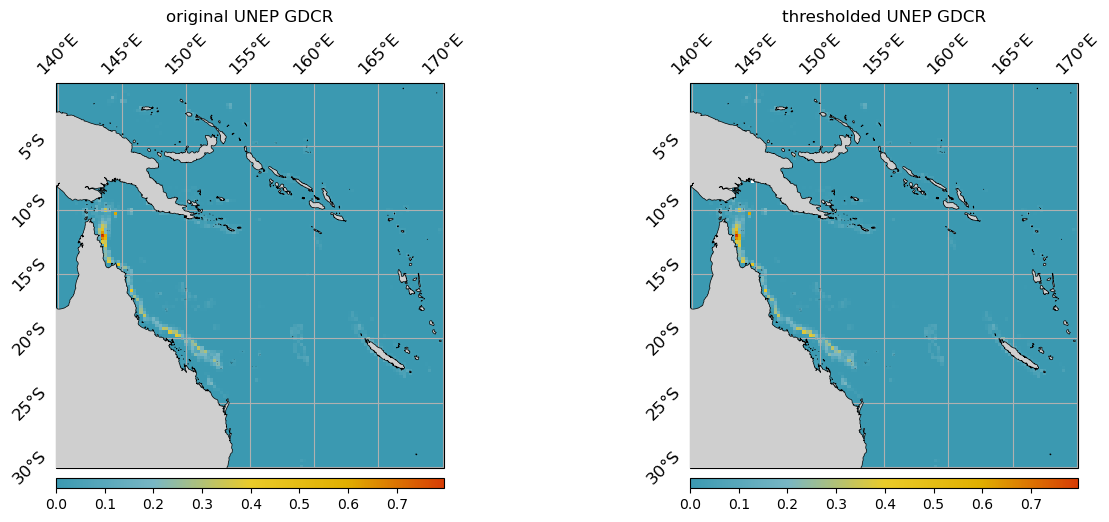

In [133]:
fig, ax = plt.subplots(1,2, figsize=(15, 5), subplot_kw={"projection": ccrs.PlateCarree()})

spatial_plots.plot_spatial(unep_gdcr, fax=(fig, ax[0]), title="original UNEP GDCR", cbar_dict={"orientation": "horizontal"})
spatial_plots.plot_spatial(thresholded, fax=(fig, ax[1]), title="thresholded UNEP GDCR", cbar_dict={"orientation": "horizontal"})